# Equity curve — Johansen spread strategy

Runs the strategy in `johansen.py` (current defaults: `LOOKBACK`, `ENTRY_Z` at the top of that file) through the same PnL loop as `eval.py` — identical commissions, position clipping, and scoring — and plots the daily portfolio value with in-trade periods shaded.

By default this uses only the **train set (first 70% of days)**. Flip `USE_HOLDOUT = True` for the one-time final validation on the full dataset — don't iterate on it.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from johansen import SpreadStrategy, BASKET

prcAll = pd.read_csv("prices.txt", sep=r"\s+", header=0, index_col=None).values.T
nInst, nt = prcAll.shape

USE_HOLDOUT = False  # flip to True ONCE for final validation on the full dataset
nDays = nt if USE_HOLDOUT else int(nt * 0.7)
prcHist = prcAll[:, :nDays]
print(f"{nInst} instruments; using first {nDays} of {nt} days")

51 instruments; using first 350 of 500 days


In [7]:
def run_equity(strategy, prcHist):
    """eval.py's PnL loop, recording the daily portfolio value and trade state."""
    nInst, nt = prcHist.shape
    commRate = np.full(nInst, 0.0001)
    commRate[0] = 0.00002
    dlrPosLimit = np.full(nInst, 10_000.0)
    dlrPosLimit[0] = 100_000.0

    startDay = strategy.lookback + 1
    cash, value, comm = 0.0, 0.0, 0.0
    curPos = np.zeros(nInst)
    tradeDir = 0
    zVal = np.nan
    rows = []

    for t in range(startDay, nt + 1):
        prcSoFar = prcHist[:, :t]
        curPrices = prcSoFar[:, -1]
        if t < nt:
            newPos = strategy.step(prcSoFar)
            tradeDir = strategy.tradeDir
            zVal = strategy.lastZ
            posLimits = (dlrPosLimit / curPrices).astype(int)
            newPos = np.clip(newPos, -posLimits, posLimits).astype(int)
        else:
            newPos = np.array(curPos)

        deltaPos = newPos - curPos
        cash -= curPrices.dot(deltaPos) + comm
        dvolumes = curPrices * np.abs(deltaPos)
        comm = np.sum(dvolumes * commRate)
        curPos = np.array(newPos)
        newValue = cash + curPos.dot(curPrices)
        rows.append({
            "day": t,
            "value": newValue,
            "todayPL": newValue - value,
            "tradeDir": tradeDir,
            "z": zVal,
            "grossDlr": np.sum(np.abs(curPos * curPrices)),
            "scored": t > startDay,
        })
        value = newValue

    return pd.DataFrame(rows)

In [8]:
strategy = SpreadStrategy()  # picks up the defaults in johansen.py
hist = run_equity(strategy, prcHist)

pll = hist.loc[hist["scored"], "todayPL"].values
mu, sd = pll.mean(), pll.std()
sharpe = np.sqrt(250) * mu / sd if sd > 0 else 0.0
scoreVal = mu * sharpe**2 / (sharpe**2 + 1.0) if mu > 0 and sd > 1e-10 else mu
d = hist["tradeDir"].values
entries = int(np.sum((d[1:] != 0) & (d[:-1] == 0)) + (d[0] != 0))

print(f"LOOKBACK={strategy.lookback}  ENTRY_Z={strategy.entry_z}")
print(f"scored days:   {len(pll)}")
print(f"mean(PL):      {mu:.2f}")
print(f"StdDev(PL):    {sd:.2f}")
print(f"annSharpe:     {sharpe:.2f}")
print(f"Score:         {scoreVal:.2f}")
print(f"entries:       {entries}")
print(f"final value:   {hist['value'].iloc[-1]:.2f}")

LOOKBACK=35  ENTRY_Z=0.75
scored days:   314
mean(PL):      28.36
StdDev(PL):    226.40
annSharpe:     1.98
Score:         22.60
entries:       32
final value:   8904.38


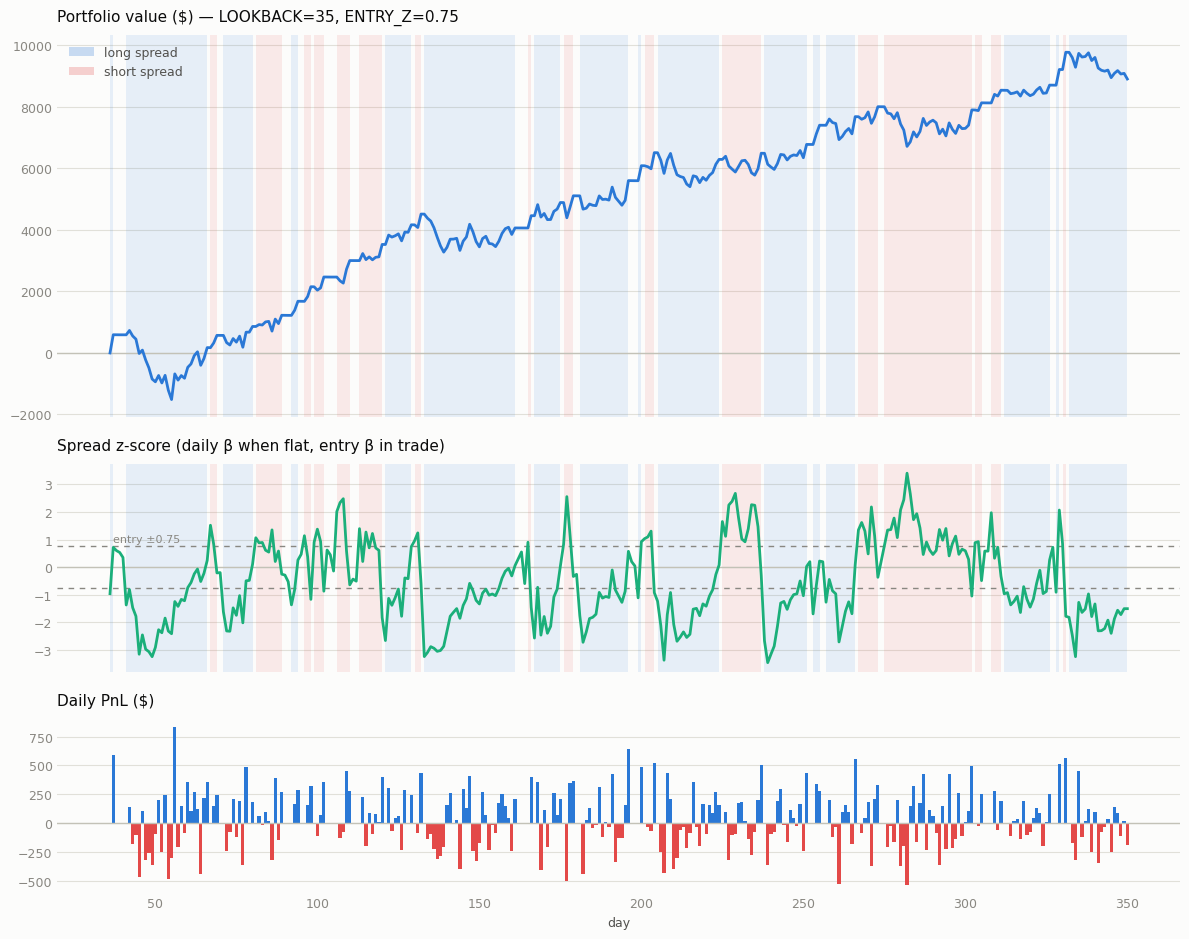

In [9]:
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
BLUE, RED, AQUA = "#2a78d6", "#e34948", "#1baf7a"


def _spans(mask, days):
    """Contiguous (start, end) day spans where mask is True."""
    out, start = [], None
    for i, m in enumerate(mask):
        if m and start is None:
            start = days[i]
        elif not m and start is not None:
            out.append((start, days[i]))
            start = None
    if start is not None:
        out.append((start, days[-1]))
    return out


def _style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)
    for s in ax.spines.values():
        s.set_visible(False)


def _shadeTrades(ax):
    for a, b in _spans(dirs == 1, days):
        ax.axvspan(a, b, color=BLUE, alpha=0.10, linewidth=0)
    for a, b in _spans(dirs == -1, days):
        ax.axvspan(a, b, color=RED, alpha=0.10, linewidth=0)


days = hist["day"].values
dirs = hist["tradeDir"].values

fig, (ax1, axz, ax2) = plt.subplots(
    3, 1, figsize=(12, 9.5), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.2, 1]},
)
fig.patch.set_facecolor(SURFACE)

_shadeTrades(ax1)
ax1.axhline(0, color=BASELINE, linewidth=1)
ax1.plot(days, hist["value"], color=BLUE, linewidth=2)
_style(ax1)
ax1.set_title(
    f"Portfolio value ($) — LOOKBACK={strategy.lookback}, ENTRY_Z={strategy.entry_z}",
    color=INK, fontsize=11, loc="left", pad=10,
)
ax1.legend(
    handles=[
        Patch(facecolor=BLUE, alpha=0.25, label="long spread"),
        Patch(facecolor=RED, alpha=0.25, label="short spread"),
    ],
    frameon=False, loc="upper left", fontsize=9, labelcolor=INK2,
)

_shadeTrades(axz)
axz.axhline(0, color=BASELINE, linewidth=1)
for thr in (strategy.entry_z, -strategy.entry_z):
    axz.axhline(thr, color=MUTED, linewidth=1, linestyle=(0, (4, 4)))
axz.plot(days, hist["z"], color=AQUA, linewidth=2)
axz.annotate(
    f"entry ±{strategy.entry_z:g}", xy=(days[0], strategy.entry_z),
    xytext=(2, 3), textcoords="offset points", fontsize=8, color=MUTED,
)
_style(axz)
axz.set_title(
    "Spread z-score (daily β when flat, entry β in trade)",
    color=INK, fontsize=11, loc="left", pad=10,
)

plCol = np.where(hist["todayPL"] >= 0, BLUE, RED)
ax2.axhline(0, color=BASELINE, linewidth=1)
ax2.bar(days, hist["todayPL"], width=1.0, color=plCol, linewidth=0)
_style(ax2)
ax2.set_title("Daily PnL ($)", color=INK, fontsize=11, loc="left", pad=10)
ax2.set_xlabel("day", color=INK2, fontsize=9)

fig.tight_layout()
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller
from johansen import _estimateBeta

# spread over the whole loaded window, with beta estimated once on all of it
logP = np.log(prcHist[BASKET, :])
betaFull = _estimateBeta(logP)
spread = betaFull @ logP

stat, pval, usedLag, nobs, crit, _ = adfuller(spread)

print(f"beta (AENO, DUCT, MHRM, NWIG): {np.round(betaFull, 4)}")
print(f"ADF statistic: {stat:.4f}")
print(f"p-value:       {pval:.4f}")
print(f"lags used:     {usedLag}   obs: {nobs}")
for name, cv in crit.items():
    print(f"  {name} critical value: {cv:.4f}")
if pval < 0.05:
    print("=> reject unit root at 5%: spread is stationary")
else:
    print("=> cannot reject unit root at 5%: spread NOT stationary")

beta (AENO, DUCT, MHRM, NWIG): [ 0.9697  0.206  -0.2596 -1.    ]
ADF statistic: -5.9357
p-value:       0.0000
lags used:     2   obs: 347
  1% critical value: -3.4493
  5% critical value: -2.8699
  10% critical value: -2.5712
=> reject unit root at 5%: spread is stationary
